In [1]:
from moabb.paradigms import FilterBankMotorImagery, MotorImagery
from moabb.datasets import *

dataset = AlexMI()

sfreq=250
paradigm = MotorImagery(n_classes=len(dataset.event_id), resample=sfreq)


Choosing from all possible events


In [2]:
from sklearn.preprocessing import FunctionTransformer

from classification_mi import stf_transform 

cache_config = dict(
    use=True,
    save_raw=False,
    save_epochs=False,
    save_array=True,
    overwrite_raw=False,
    overwrite_epochs=False,
    overwrite_array=False,
)

X, y, meta = paradigm.get_data(
     dataset=dataset, 
     subjects=[1],
     return_epochs=False,
     postprocess_pipeline = FunctionTransformer(stf_transform),
     cache_config=cache_config,

)



In [3]:
import tensorly as tl
from bttda.classification import ZScore
import pandas as pd

X = tl.tensor(X)
X = ZScore().fit_transform(X)

In [4]:
from bttda.hoda import BTTDA

bttda = BTTDA(
    ranks=[None]*8,
    hoda_params=dict(
        rank=None,
        shrinkage='lw',
        obj='tr',
        verbose=True,
        theta=0.2,
    ),
    verbose=True,
    extra_train_info=True,

)
bttda.fit(X,y)

Fitting block 1/8...


Forward model :  13%|█▎        | 34/255 [00:00<00:01, 187.15it/s]


Fitting block 2/8...


Forward model :  51%|█████▏    | 131/255 [00:00<00:00, 216.90it/s]


Fitting block 3/8...


...

Fitting block 7/8...


Forward model :  27%|██▋       | 69/255 [00:00<00:00, 197.07it/s]


Fitting block 8/8...


Forward model :  30%|██▉       | 76/255 [00:00<00:01, 125.40it/s]


BTTDA(hoda_params={'obj': 'tr', 'rank': None, 'shrinkage': 'lw', 'theta': 0.2,
                   'verbose': True},
      ranks=[None, None, None, None, None, None, None, None], verbose=True)

In [5]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

,block,rank
0,1,"(1, 2, 2)"
1,2,"(1, 2, 2)"
2,3,"(1, 2, 2)"
3,4,"(1, 2, 2)"
4,5,"(1, 2, 2)"
5,6,"(1, 2, 2)"
6,7,"(1, 2, 2)"
7,8,"(1, 2, 2)"


In [6]:
import plotly.express as px

if bttda.extra_train_info:
    fig = px.line(df, x='block', y='F_tr')
    fig.show()


In [7]:
if bttda.extra_train_info:
    fig = px.line(df, x='block', y='F_rt')
    fig.show()


In [8]:
if bttda.extra_train_info:
    fig = px.line(df, x='block', y='nmse')
    fig.show()


In [9]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from bttda.classification import SelectFCutoff

Xt = bttda.transform(X)
xt = tl.to_numpy(tl.unfold(Xt,0))

select = SelectFCutoff()
xts = select.fit_transform(xt,y)

df = pd.DataFrame({
    'feature': np.arange(xt.shape[-1]),
    'F': select.scores_,
    'significant': select.scores_>1,
})
df

,feature,F,significant
0,0,115.156358,True
1,1,26.125697,True
2,2,1.943965,True
3,3,0.298720,False
4,4,139.576778,True
5,5,40.966077,True
6,6,1.479466,True
7,7,19.425813,True
8,8,138.318931,True
9,9,95.392957,True


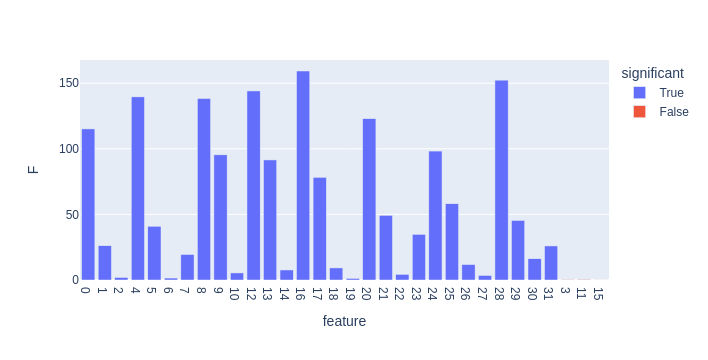

In [19]:
fig = px.bar(df, x='feature', y='F', color='significant', log_y=True)
fig.update_xaxes(type='category', categoryorder='total descending')
fig.show()

In [11]:
from sklearn.decomposition import PCA

x_viz = PCA(n_components=2, whiten=True).fit_transform(xts)
fig = px.scatter(x=x_viz[:,0], y=x_viz[:,1], color=y)
fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
  )

In [12]:
from bttda.hoda import f_multiway

print(f"trace-ratio: {f_multiway(xts,y, method='tr')}")
print(f"ratio-trace: {f_multiway(xts,y, method='rt')}")

trace-ratio: 3.535537395851095
ratio-trace: 2.0846613372435803


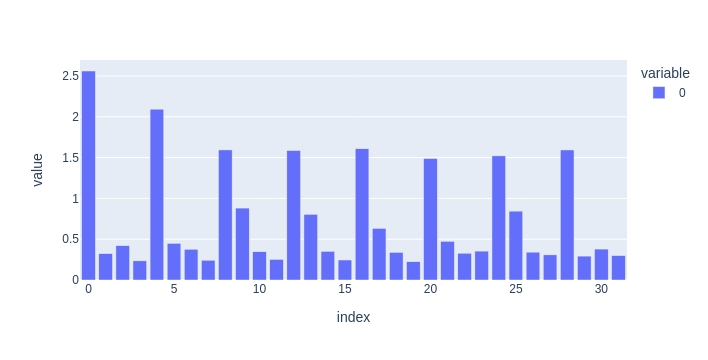

In [17]:
px.bar(np.std(tl.to_numpy(Xt), axis=0))